# USD/ETB Exchange Rate Analysis & Forecasting
This notebook analyzes the historical exchange rate of USD to ETB, focusing on the July 2024 currency float.

In [8]:
# Install dependencies
# !pip install yfinance pandas numpy matplotlib statsmodels scikit-learn

In [9]:
%pip install yfinance statsmodels

Defaulting to user installation because normal site-packages is not writeable

[notice] A new release of pip is available: 26.0.1 -> 26.1.2
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [10]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.stattools import adfuller
from statsmodels.tsa.arima.model import ARIMA
from datetime import datetime

plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)
print('import done!')

import done!


In [11]:
# Fetch historical USD/ETB data
ticker = 'USDETB=X'
df = yf.download(ticker, start='2022-01-01', end=datetime.today().strftime('%Y-%m-%d'))
df.index = pd.to_datetime(df.index)
df = df[['Close']].rename(columns={'Close': 'Rate'})
df.dropna(inplace=True)
df.head()

[*********************100%***********************]  1 of 1 completed


Price,Rate
Ticker,USDETB=X
Date,
2022-01-03,49.000000
2022-01-04,49.099998
2022-01-05,49.200001
2022-01-06,49.250000
2022-01-07,49.200001


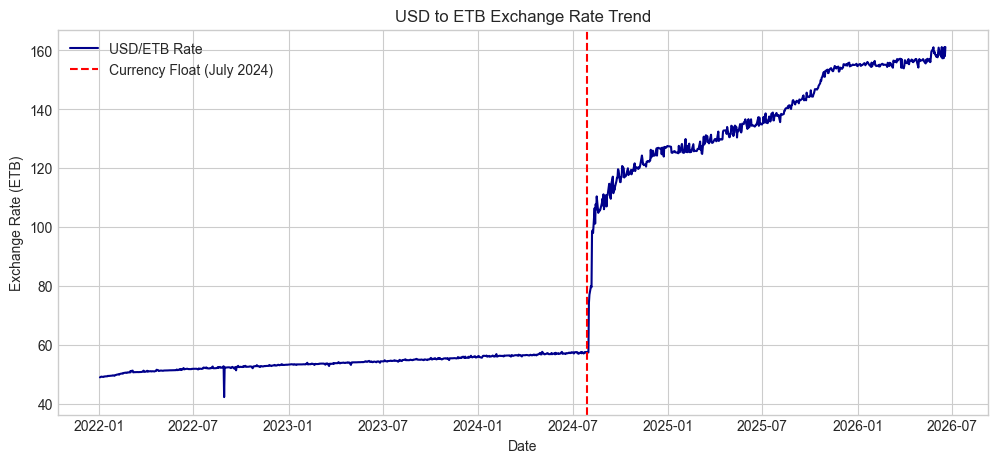

In [12]:
# Plot Trend & Highlight Float Transition (July 2024)
plt.figure(figsize=(12, 5))
plt.plot(df.index, df['Rate'], label='USD/ETB Rate', color='darkblue')
plt.axvline(pd.to_datetime('2024-07-29'), color='red', linestyle='--', label='Currency Float (July 2024)')
plt.title('USD to ETB Exchange Rate Trend')
plt.xlabel('Date')
plt.ylabel('Exchange Rate (ETB)')
plt.legend()
plt.show()

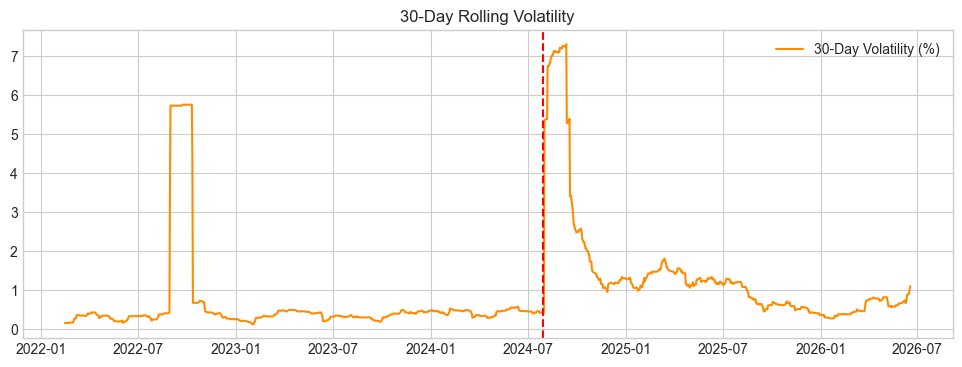

In [13]:
# Volatility Analysis
df['Daily_Return'] = df['Rate'].pct_change()
df['Rolling_Vol_30D'] = df['Daily_Return'].rolling(window=30).std() * 100

plt.figure(figsize=(12, 4))
plt.plot(df.index, df['Rolling_Vol_30D'], color='darkorange', label='30-Day Volatility (%)')
plt.axvline(pd.to_datetime('2024-07-29'), color='red', linestyle='--')
plt.title('30-Day Rolling Volatility')
plt.legend()
plt.show()

In [14]:
# Stationarity Analysis (on Post-Float Data)
post_float_df = df[df.index >= '2024-08-01'].copy()
result = adfuller(post_float_df['Rate'].dropna())
print('ADF Statistic: %f' % result[0])
print('p-value: %f' % result[1])

ADF Statistic: -2.353091
p-value: 0.155416


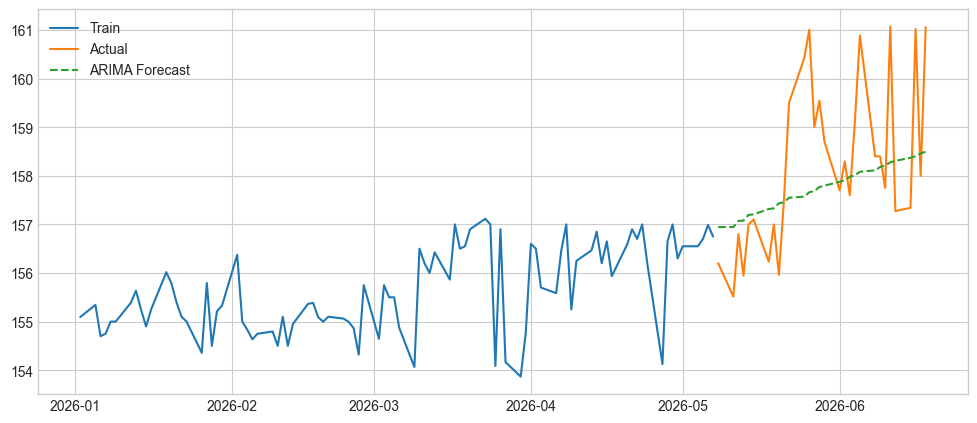

In [17]:
# Baseline forecasts & ARIMA
train_data = post_float_df['Rate'].iloc[:-30]
test_data = post_float_df['Rate'].iloc[-30:]

model = ARIMA(train_data, order=(2, 1, 3))
model_fitted = model.fit()
forecast = model_fitted.get_forecast(steps=30)
forecast_series = forecast.predicted_mean
forecast_series.index = test_data.index

# Plot Forecast
plt.figure(figsize=(12, 5))
plt.plot(train_data.index[-90:], train_data.iloc[-90:], label='Train')
plt.plot(test_data.index, test_data, label='Actual')
plt.plot(forecast_series.index, forecast_series, label='ARIMA Forecast', linestyle='--')
plt.legend()
plt.show()

In [18]:
import warnings
warnings.filterwarnings('ignore')

# Grid search for the best ARIMA parameters
best_aic = float("inf")
best_order = None

p_values = range(0, 4) # Autoregressive terms
d_values = [1]        # Keep differencing at 1 since we proved it is non-stationary
q_values = range(0, 4) # Moving average terms

print("Searching for the optimal ARIMA parameters...")
for p in p_values:
    for d in d_values:
        for q in q_values:
            try:
                # Fit model on training data
                temp_model = ARIMA(train_data, order=(p, d, q))
                results = temp_model.fit()
                
                # Check model is better
                if results.aic < best_aic:
                    best_aic = results.aic
                    best_order = (p, d, q)
            except:
                continue

print(f"\nBest ARIMA Order found: ARIMA{best_order}")
print(f"Lowest AIC Score: {best_aic:.2f}")

Searching for the optimal ARIMA parameters...

Best ARIMA Order found: ARIMA(2, 1, 3)
Lowest AIC Score: 1760.76


In [19]:
# Evaluation
from sklearn.metrics import mean_squared_error, mean_absolute_error
import numpy as np
mae = mean_absolute_error(test_data, forecast_series)
rmse = np.sqrt(mean_squared_error(test_data, forecast_series))
print(f'MAE: {mae:.4f}')
print(f'RMSE: {rmse:.4f}')

MAE: 1.1755
RMSE: 1.5227


## Conclusion & Project Summary

### Summary of Results
- **Baseline Model [ARIMA(1,1,1)]:** MAE: 1.7156 | RMSE: 2.2031
- **Optimized Model [ARIMA(2,1,3)]:** MAE: 1.1755 | RMSE: 1.5227
- **Improvement:** Tuning the parameters resulted in a **~31% reduction in prediction error**. On average, the optimized model's predictions deviated from the actual post-float exchange rate by only **0.74%** over a 30-day period.

### Project Limitations & Fintech Realities
While the ARIMA model performed exceptionally well on this test window, it is important to note the real-world limitations of purely statistical models in currency markets:
1. **No External Features:** ARIMA relies solely on past price data. In reality, exchange rates are heavily driven by macroeconomic indicators (inflation, trade balances, GDP growth), political events, and central bank interventions.
2. **Policy Shifts:** As demonstrated by the transition in July 2024, sudden regulatory changes or peg adjustments can make historical data irrelevant overnight.